In [4]:
!pip install -q torch torchvision scikit-learn seaborn matplotlib

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

classes = train_dataset.classes
print("Classes:", classes)
print("Training set size:", len(train_dataset))
print("Testing set size :", len(test_dataset))
print("Single image shape:", train_dataset[0][0].shape)

# Split a validation set out of the training set
val_size = 5000
train_size = len(train_dataset) - val_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 32
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 170M/170M [33:52<00:00, 83.9kB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training set size: 50000
Testing set size : 10000
Single image shape: torch.Size([3, 32, 32])


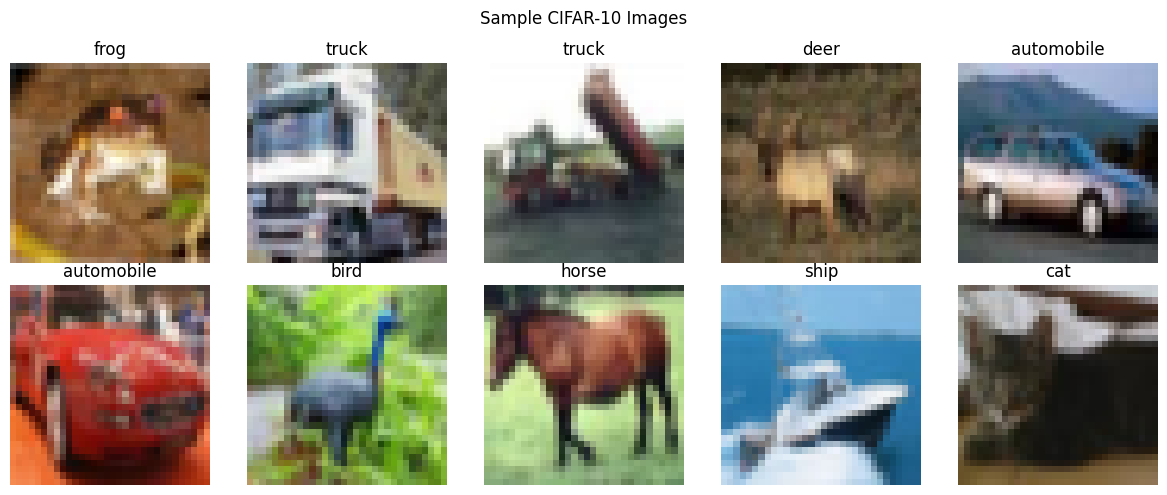

In [6]:
# --- Mandatory Plot 1: Sample Images ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(classes[label])
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()

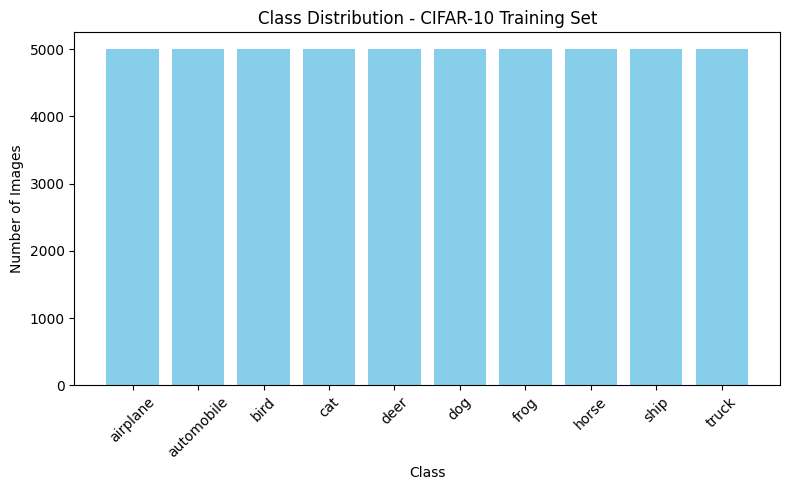

In [7]:
# --- Mandatory Plot 2: Class Distribution ---
labels_all = np.array(train_dataset.targets)
unique, counts = np.unique(labels_all, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar([classes[i] for i in unique], counts, color='skyblue')
plt.xlabel('Class'); plt.ylabel('Number of Images')
plt.title('Class Distribution - CIFAR-10 Training Set')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

In [8]:
sample_img, _ = train_dataset[0]
sample_img = sample_img.unsqueeze(0)  # shape: (1, 3, 32, 32)

print("Task 2: Feature map size for different kernel sizes (stride=1, padding=0)\n")
kernel_sizes = [3, 5, 7]
for k in kernel_sizes:
    conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=k, stride=1, padding=0)
    out = conv(sample_img)
    N, S, P = 32, 1, 0
    expected = (N - k + 2 * P) // S + 1
    print(f"Kernel {k}x{k} -> Output feature map: {out.shape[2]}x{out.shape[3]}  (formula check: {expected}x{expected})")

Task 2: Feature map size for different kernel sizes (stride=1, padding=0)

Kernel 3x3 -> Output feature map: 30x30  (formula check: 30x30)
Kernel 5x5 -> Output feature map: 28x28  (formula check: 28x28)
Kernel 7x7 -> Output feature map: 26x26  (formula check: 26x26)


In [9]:
print("Task 3: Effect of stride and padding on output size (3x3 kernel)\n")
configs = [
    {"stride": 1, "padding": 0, "label": "Stride=1, Padding=Valid (0)"},
    {"stride": 2, "padding": 0, "label": "Stride=2, Padding=Valid (0)"},
    {"stride": 1, "padding": 1, "label": "Stride=1, Padding=Same (1) for 3x3 kernel"},
    {"stride": 2, "padding": 1, "label": "Stride=2, Padding=1"},
]

for cfg in configs:
    conv = nn.Conv2d(3, 1, kernel_size=3, stride=cfg["stride"], padding=cfg["padding"])
    out = conv(sample_img)
    N, Fk, P, S = 32, 3, cfg["padding"], cfg["stride"]
    formula = (N - Fk + 2 * P) // S + 1
    print(f"{cfg['label']:45s} -> Output: {out.shape[2]}x{out.shape[3]}  (formula={formula}x{formula})")

Task 3: Effect of stride and padding on output size (3x3 kernel)

Stride=1, Padding=Valid (0)                   -> Output: 30x30  (formula=30x30)
Stride=2, Padding=Valid (0)                   -> Output: 15x15  (formula=15x15)
Stride=1, Padding=Same (1) for 3x3 kernel     -> Output: 32x32  (formula=32x32)
Stride=2, Padding=1                           -> Output: 16x16  (formula=16x16)


In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_filters1=16, num_filters2=32, pool_type='max', activation='relu'):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, num_filters1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(num_filters1, num_filters2, kernel_size=3, padding=1)

        if pool_type == 'max':
            self.pool1 = nn.MaxPool2d(2, 2)
            self.pool2 = nn.MaxPool2d(2, 2)
        else:
            self.pool1 = nn.AvgPool2d(2, 2)
            self.pool2 = nn.AvgPool2d(2, 2)

        self.activation_type = activation
        flat_size = num_filters2 * 8 * 8  # 32 -> 16 -> 8 after two pool layers
        self.fc = nn.Linear(flat_size, 10)

    def _activate(self, x):
        if self.activation_type == 'relu':
            return F.relu(x)
        elif self.activation_type == 'sigmoid':
            return torch.sigmoid(x)
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'")

    def forward(self, x, return_features=False):
        x1 = self._activate(self.conv1(x))
        p1 = self.pool1(x1)
        x2 = self._activate(self.conv2(p1))
        p2 = self.pool2(x2)
        flat = p2.view(p2.size(0), -1)
        logits = self.fc(flat)
        if return_features:
            return logits, x1  # x1 = feature maps after first conv layer
        return logits

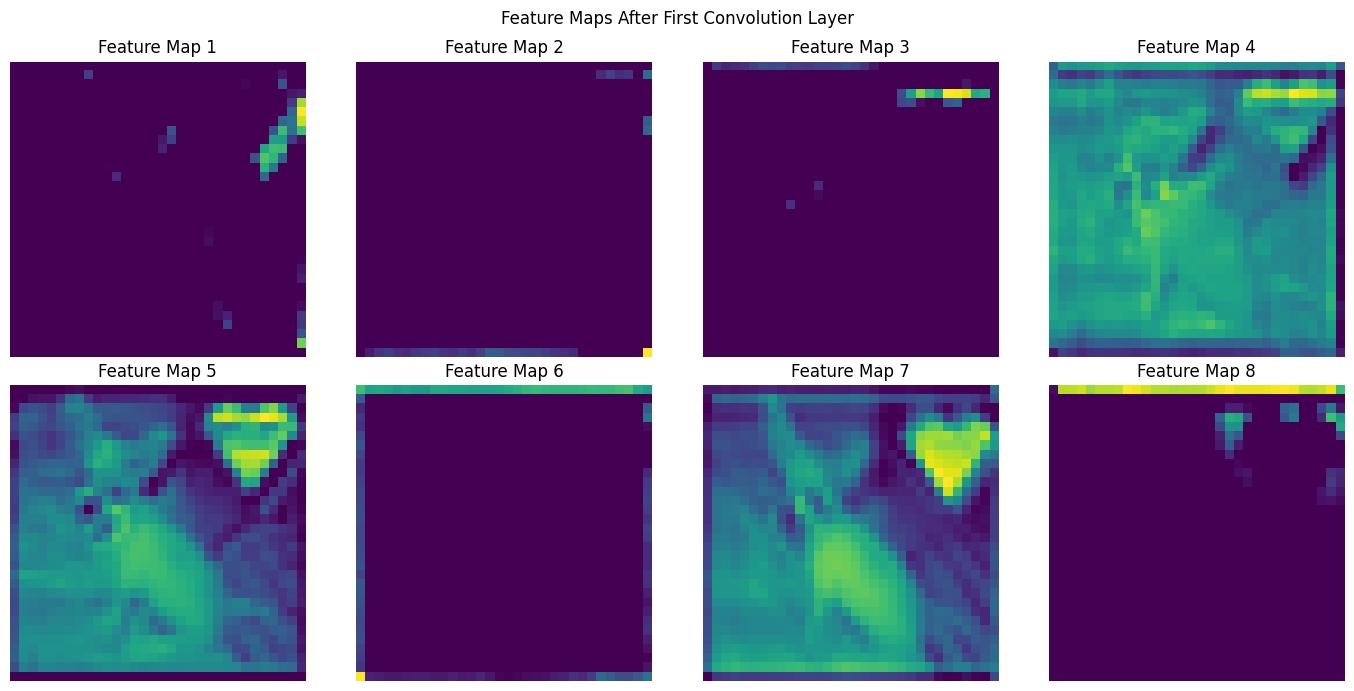

In [11]:
demo_model = SimpleCNN().to(device)
demo_model.eval()

sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(device)
with torch.no_grad():
    _, feature_maps = demo_model(sample_batch, return_features=True)
feature_maps = feature_maps.cpu()

# --- Mandatory Plot 7: Feature Maps (at least 8) ---
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, i], cmap='viridis')
    ax.set_title(f'Feature Map {i + 1}')
    ax.axis('off')
plt.suptitle('Feature Maps After First Convolution Layer')
plt.tight_layout()
plt.savefig('feature_maps.png')
plt.show()

In [12]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
                  f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    return history

Task 5: Max Pooling vs Average Pooling

Epoch 1/5 | Train Loss: 1.5157 Acc: 0.4610 | Val Loss: 1.3309 Acc: 0.5376
Epoch 2/5 | Train Loss: 1.2192 Acc: 0.5727 | Val Loss: 1.2453 Acc: 0.5548
Epoch 3/5 | Train Loss: 1.0934 Acc: 0.6180 | Val Loss: 1.0627 Acc: 0.6300
Epoch 4/5 | Train Loss: 1.0062 Acc: 0.6514 | Val Loss: 1.0386 Acc: 0.6354
Epoch 5/5 | Train Loss: 0.9487 Acc: 0.6719 | Val Loss: 0.9770 Acc: 0.6654

Epoch 1/5 | Train Loss: 1.5897 Acc: 0.4349 | Val Loss: 1.3709 Acc: 0.5148
Epoch 2/5 | Train Loss: 1.3015 Acc: 0.5407 | Val Loss: 1.2531 Acc: 0.5606
Epoch 3/5 | Train Loss: 1.1986 Acc: 0.5800 | Val Loss: 1.1874 Acc: 0.5852
Epoch 4/5 | Train Loss: 1.1284 Acc: 0.6060 | Val Loss: 1.1410 Acc: 0.6044
Epoch 5/5 | Train Loss: 1.0782 Acc: 0.6238 | Val Loss: 1.1027 Acc: 0.6186

Max Pooling  - Final Val Accuracy: 0.6654
Avg Pooling  - Final Val Accuracy: 0.6186


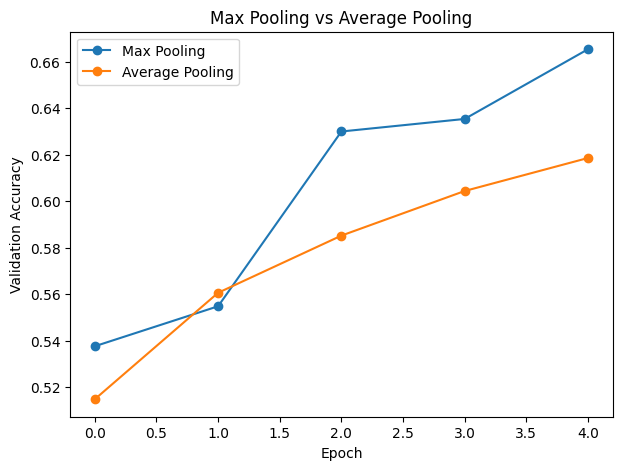

In [13]:
print("Task 5: Max Pooling vs Average Pooling\n")

model_max = SimpleCNN(pool_type='max')
history_max = train_model(model_max, train_loader, val_loader, epochs=5)

print()
model_avg = SimpleCNN(pool_type='avg')
history_avg = train_model(model_avg, train_loader, val_loader, epochs=5)

print(f"\nMax Pooling  - Final Val Accuracy: {history_max['val_acc'][-1]:.4f}")
print(f"Avg Pooling  - Final Val Accuracy: {history_avg['val_acc'][-1]:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(history_max['val_acc'], label='Max Pooling', marker='o')
plt.plot(history_avg['val_acc'], label='Average Pooling', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.title('Max Pooling vs Average Pooling'); plt.legend()
plt.savefig('pooling_comparison.png'); plt.show()

In [14]:
print("Task 6: Training main CNN (16 -> 32 filters, MaxPool, ReLU, Adam, 20 epochs)\n")

main_model = SimpleCNN(num_filters1=16, num_filters2=32, pool_type='max', activation='relu')
history_main = train_model(main_model, train_loader, val_loader, epochs=20, lr=0.001)

Task 6: Training main CNN (16 -> 32 filters, MaxPool, ReLU, Adam, 20 epochs)

Epoch 1/20 | Train Loss: 1.5270 Acc: 0.4570 | Val Loss: 1.3377 Acc: 0.5252
Epoch 2/20 | Train Loss: 1.2266 Acc: 0.5686 | Val Loss: 1.1555 Acc: 0.5946
Epoch 3/20 | Train Loss: 1.0923 Acc: 0.6170 | Val Loss: 1.0870 Acc: 0.6238
Epoch 4/20 | Train Loss: 1.0083 Acc: 0.6488 | Val Loss: 1.0959 Acc: 0.6098
Epoch 5/20 | Train Loss: 0.9496 Acc: 0.6703 | Val Loss: 0.9933 Acc: 0.6542
Epoch 6/20 | Train Loss: 0.9109 Acc: 0.6844 | Val Loss: 0.9846 Acc: 0.6594
Epoch 7/20 | Train Loss: 0.8734 Acc: 0.6964 | Val Loss: 0.9957 Acc: 0.6582
Epoch 8/20 | Train Loss: 0.8429 Acc: 0.7083 | Val Loss: 0.9670 Acc: 0.6648
Epoch 9/20 | Train Loss: 0.8244 Acc: 0.7128 | Val Loss: 0.9645 Acc: 0.6692
Epoch 10/20 | Train Loss: 0.8006 Acc: 0.7224 | Val Loss: 0.9708 Acc: 0.6710
Epoch 11/20 | Train Loss: 0.7810 Acc: 0.7285 | Val Loss: 0.9593 Acc: 0.6702
Epoch 12/20 | Train Loss: 0.7646 Acc: 0.7348 | Val Loss: 1.0034 Acc: 0.6578
Epoch 13/20 | Train

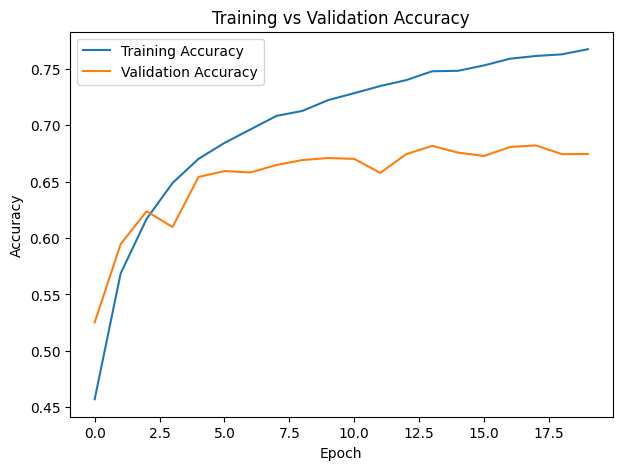

In [15]:
# --- Mandatory Plot 3 & 4: Training / Validation Accuracy ---
plt.figure(figsize=(7, 5))
plt.plot(history_main['train_acc'], label='Training Accuracy')
plt.plot(history_main['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy'); plt.legend()
plt.savefig('accuracy_plot.png'); plt.show()

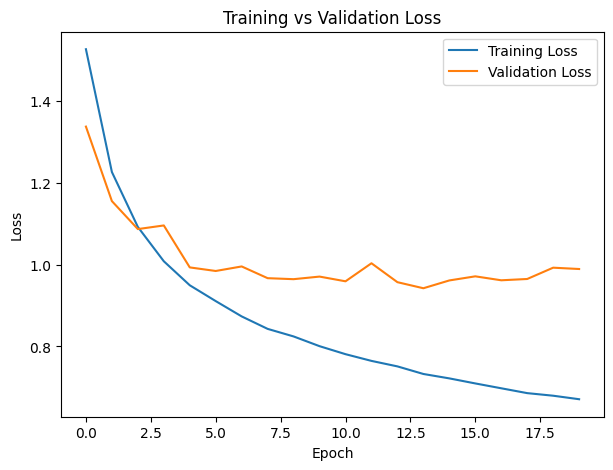

In [17]:
# --- Mandatory Plot 5 & 6: Training / Validation Loss ---
plt.figure(figsize=(7, 5))
plt.plot(history_main['train_loss'], label='Training Loss')
plt.plot(history_main['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss'); plt.legend()
plt.savefig('loss_plot.png'); plt.show()

In [18]:
main_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = main_model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = np.mean(all_preds == all_labels)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Precision (macro)   : {precision:.4f}")
print(f"Recall (macro)      : {recall:.4f}")
print(f"F1-score (macro)    : {f1:.4f}")

total_params = sum(p.numel() for p in main_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

Test Accuracy       : 0.6783
Precision (macro)   : 0.6835
Recall (macro)      : 0.6783
F1-score (macro)    : 0.6774
Total trainable parameters: 25578

Classification Report:

              precision    recall  f1-score   support

    airplane       0.78      0.64      0.70      1000
  automobile       0.85      0.74      0.79      1000
        bird       0.53      0.62      0.57      1000
         cat       0.50      0.47      0.49      1000
        deer       0.67      0.61      0.64      1000
         dog       0.61      0.56      0.58      1000
        frog       0.76      0.75      0.75      1000
       horse       0.74      0.71      0.72      1000
        ship       0.67      0.88      0.76      1000
       truck       0.71      0.81      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



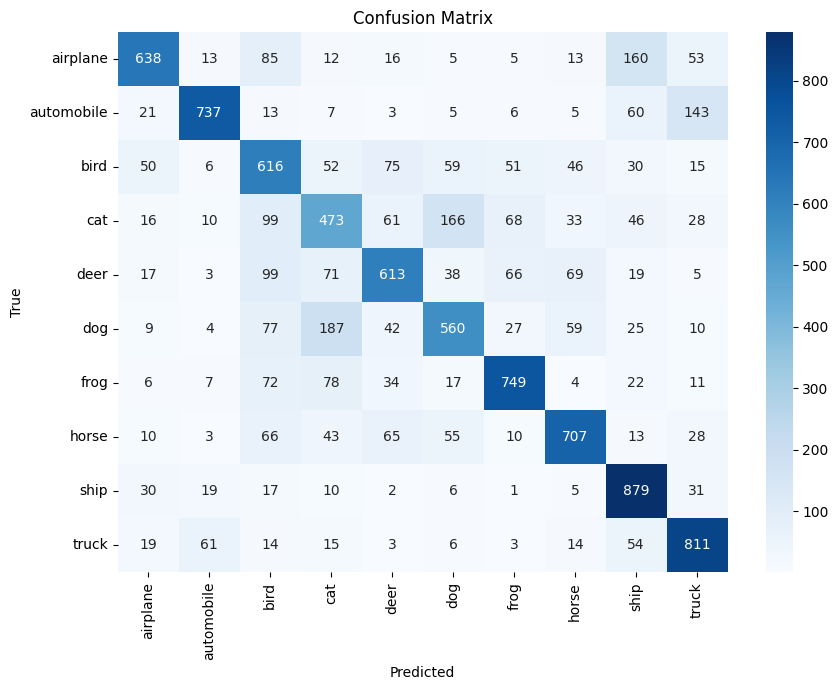

In [19]:
# --- Mandatory Plot 8: Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [20]:
N, Fk, P, S = 64, 5, 2, 2
out_size = (N - Fk + 2 * P) // S + 1
print(f"Additional Exercise 1: Output size = {out_size}x{out_size}")

Additional Exercise 1: Output size = 32x32


In [21]:
filters, k, in_ch = 64, 3, 3
params = (k * k * in_ch + 1) * filters
print(f"Additional Exercise 2: Trainable parameters = {params}")

Additional Exercise 2: Trainable parameters = 1792


Additional Exercise 3: ReLU vs Sigmoid

Epoch 1/5 | Train Loss: 1.5333 Acc: 0.4540 | Val Loss: 1.3392 Acc: 0.5188
Epoch 2/5 | Train Loss: 1.2146 Acc: 0.5742 | Val Loss: 1.1663 Acc: 0.5858
Epoch 3/5 | Train Loss: 1.0904 Acc: 0.6197 | Val Loss: 1.1042 Acc: 0.6136
Epoch 4/5 | Train Loss: 1.0135 Acc: 0.6467 | Val Loss: 1.0520 Acc: 0.6312
Epoch 5/5 | Train Loss: 0.9534 Acc: 0.6698 | Val Loss: 0.9989 Acc: 0.6542

Epoch 1/5 | Train Loss: 2.1023 Acc: 0.2325 | Val Loss: 1.9244 Acc: 0.3086
Epoch 2/5 | Train Loss: 1.7958 Acc: 0.3661 | Val Loss: 1.7200 Acc: 0.3938
Epoch 3/5 | Train Loss: 1.6539 Acc: 0.4128 | Val Loss: 1.6247 Acc: 0.4142
Epoch 4/5 | Train Loss: 1.5729 Acc: 0.4424 | Val Loss: 1.5556 Acc: 0.4404
Epoch 5/5 | Train Loss: 1.5201 Acc: 0.4595 | Val Loss: 1.5085 Acc: 0.4612


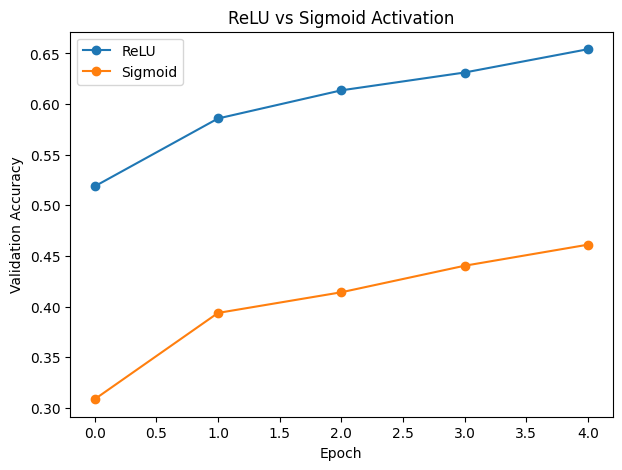


ReLU final val accuracy   : 0.6542
Sigmoid final val accuracy: 0.4612


In [22]:
print("Additional Exercise 3: ReLU vs Sigmoid\n")

model_relu = SimpleCNN(activation='relu')
hist_relu = train_model(model_relu, train_loader, val_loader, epochs=5)

print()
model_sigmoid = SimpleCNN(activation='sigmoid')
hist_sigmoid = train_model(model_sigmoid, train_loader, val_loader, epochs=5)

plt.figure(figsize=(7, 5))
plt.plot(hist_relu['val_acc'], label='ReLU', marker='o')
plt.plot(hist_sigmoid['val_acc'], label='Sigmoid', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.title('ReLU vs Sigmoid Activation'); plt.legend()
plt.savefig('relu_vs_sigmoid.png'); plt.show()

print(f"\nReLU final val accuracy   : {hist_relu['val_acc'][-1]:.4f}")
print(f"Sigmoid final val accuracy: {hist_sigmoid['val_acc'][-1]:.4f}")

Additional Exercise 5: Effect of increasing filters (16 -> 64)

Epoch 1/5 | Train Loss: 1.5253 Acc: 0.4597 | Val Loss: 1.3239 Acc: 0.5362
Epoch 2/5 | Train Loss: 1.1962 Acc: 0.5834 | Val Loss: 1.1523 Acc: 0.5954
Epoch 3/5 | Train Loss: 1.0795 Acc: 0.6278 | Val Loss: 1.0805 Acc: 0.6238
Epoch 4/5 | Train Loss: 1.0114 Acc: 0.6504 | Val Loss: 1.0349 Acc: 0.6424
Epoch 5/5 | Train Loss: 0.9658 Acc: 0.6669 | Val Loss: 1.0447 Acc: 0.6346

Epoch 1/5 | Train Loss: 1.4510 Acc: 0.4844 | Val Loss: 1.2828 Acc: 0.5562
Epoch 2/5 | Train Loss: 1.1273 Acc: 0.6055 | Val Loss: 1.0596 Acc: 0.6332
Epoch 3/5 | Train Loss: 1.0000 Acc: 0.6532 | Val Loss: 1.0293 Acc: 0.6370
Epoch 4/5 | Train Loss: 0.9319 Acc: 0.6759 | Val Loss: 0.9780 Acc: 0.6560
Epoch 5/5 | Train Loss: 0.8910 Acc: 0.6899 | Val Loss: 0.9542 Acc: 0.6720

16-filter model -> Final Val Acc: 0.6346, Training Time: 209.19s
64-filter model -> Final Val Acc: 0.6720, Training Time: 647.92s


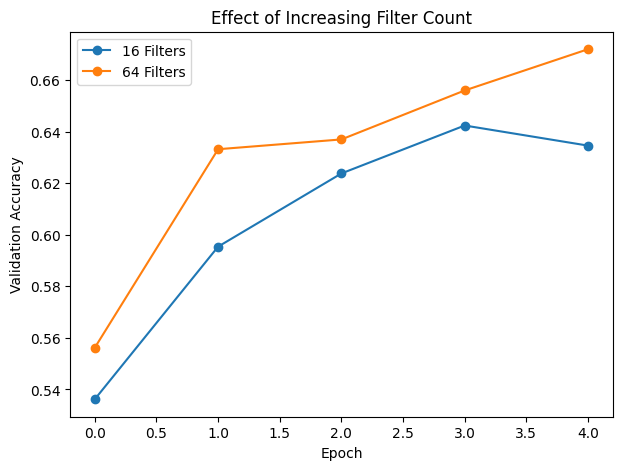

In [23]:
print("Additional Exercise 5: Effect of increasing filters (16 -> 64)\n")

model_16 = SimpleCNN(num_filters1=16, num_filters2=32)
start = time.time()
hist_16 = train_model(model_16, train_loader, val_loader, epochs=5)
time_16 = time.time() - start

print()
model_64 = SimpleCNN(num_filters1=64, num_filters2=64)
start = time.time()
hist_64 = train_model(model_64, train_loader, val_loader, epochs=5)
time_64 = time.time() - start

print(f"\n16-filter model -> Final Val Acc: {hist_16['val_acc'][-1]:.4f}, Training Time: {time_16:.2f}s")
print(f"64-filter model -> Final Val Acc: {hist_64['val_acc'][-1]:.4f}, Training Time: {time_64:.2f}s")

plt.figure(figsize=(7, 5))
plt.plot(hist_16['val_acc'], label='16 Filters', marker='o')
plt.plot(hist_64['val_acc'], label='64 Filters', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.title('Effect of Increasing Filter Count'); plt.legend()
plt.savefig('filter_count_comparison.png'); plt.show()